In [ ]:
import pandas as pd                       # Práce s datovými rámci (tabulkami)
import re                                 # Práce s regulárními výrazy (čištění textu)
import nltk                               # Přirozené zpracování jazyka (tokenizace, stop slova, lemmatizace)
from nltk.corpus import stopwords         # Stop slova pro angličtinu
from nltk.stem import WordNetLemmatizer   # Lemmatizace slov
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer # BOW a TF-IDF
from sklearn.preprocessing import LabelEncoder # Kódování kategorií na čísla
import tensorflow as tf                   # Práce s neuronovými sítěmi
import matplotlib.pyplot as plt           # Vizualizace (grafy)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Nastaví množinu stop slov a lemmatizátor.
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def preprocess_text(text):
     # text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    # stop words
    tokens = [w for w in tokens if w not in stop_words]
    # lemmatizér
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

In [ ]:
import kagglehub
path = kagglehub.dataset_download("aadyasingh55/fake-news-classification")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/fake-news-classification


In [ ]:
train_df = pd.read_csv('/content/train (2).csv', delimiter = ';')
test_df = pd.read_csv('/content/test (1).csv', delimiter = ';')

In [ ]:
print(train_df.columns)

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')


In [ ]:
df_dropped_train = train_df.drop(train_df.columns[[0, 2]], axis=1)
df_dropped_test = test_df.drop(train_df.columns[[0, 2]], axis=1)

In [ ]:
print(df_dropped_train.head())

                                               title  label
0  Palestinians switch off Christmas lights in Be...      1
1  China says Trump call with Taiwan president wo...      1
2   FAIL! The Trump Organization’s Credit Score W...      0
3  Zimbabwe military chief's China trip was norma...      1
4  THE MOST UNCOURAGEOUS PRESIDENT EVER Receives ...      0


In [ ]:
duplicates_mask = df_dropped_train.duplicated()

In [ ]:
duplicate_rows = df_dropped_train[duplicates_mask]

In [ ]:
print(duplicate_rows)

                                                   title  label
413    U.S. Navy carrier drills with Japanese navy am...      1
687                                             no title      0
910                                             no title      1
1021                                            no title      0
1063                                            no title      1
...                                                  ...    ...
24115  obamacare architect gruber demands larger mand...      0
24182  U.S. lawmakers target Myanmar military with ne...      1
24218  China, U.S. create 'miracle' with $253.4 billi...      1
24285                                           no title      0
24307  China says hopes Iran nuclear deal stays intac...      1

[290 rows x 2 columns]


In [ ]:
df_train_no_duplicates = df_dropped_train.drop_duplicates()
df_test_no_duplicates = df_dropped_test.drop_duplicates()

In [ ]:
num_rows = df_train_no_duplicates.shape[0]
print("Number of rows:", num_rows)

Number of rows: 24063


In [ ]:
df_train_no_duplicates['cleaned_text'] = df_train_no_duplicates['title'].fillna('').apply(preprocess_text)
df_test_no_duplicates['cleaned_text'] = df_test_no_duplicates['title'].fillna('').apply(preprocess_text)

/tmp/ipython-input-69-1622348159.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_no_duplicates['cleaned_text'] = df_train_no_duplicates['title'].fillna('').apply(preprocess_text)
/tmp/ipython-input-69-1622348159.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_no_duplicates['cleaned_text'] = df_test_no_duplicates['title'].fillna('').apply(preprocess_text)


In [ ]:
df_train_no_duplicates

,title,label,cleaned_text,label_enc
0,Palestinians switch off Christmas lights in Be...,1,Palestinians switch Christmas light Bethlehem ...,1
1,China says Trump call with Taiwan president wo...,1,China say Trump call Taiwan president wont cha...,1
2,FAIL! The Trump Organization’s Credit Score W...,0,FAIL The Trump Organizations Credit Score Will...,0
3,Zimbabwe military chief's China trip was norma...,1,Zimbabwe military chief China trip normal visi...,1
4,THE MOST UNCOURAGEOUS PRESIDENT EVER Receives ...,0,THE MOST UNCOURAGEOUS PRESIDENT EVER Receives ...,0
...,...,...,...,...
24348,Mexico Senate committee OK's air transport dea...,1,Mexico Senate committee OKs air transport deal...,1
24349,BREAKING: HILLARY CLINTON’S STATE DEPARTMENT G...,0,BREAKING HILLARY CLINTONS STATE DEPARTMENT GAV...,0
24350,trump breaks from stump speech to admire beaut...,0,trump break stump speech admire beautiful trum...,0
24351,NFL PLAYER Delivers Courageous Message: Stop B...,0,NFL PLAYER Delivers Courageous Message Stop Bl...,0


In [ ]:
le = LabelEncoder()
df_train_no_duplicates['label_enc'] = le.fit_transform(df_train_no_duplicates['label'])
df_test_no_duplicates['label_enc'] = le.transform(df_test_no_duplicates['label'])


/tmp/ipython-input-45-1191006198.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_no_duplicates['label_enc'] = le.fit_transform(df_train_no_duplicates['label'])
/tmp/ipython-input-45-1191006198.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_no_duplicates['label_enc'] = le.transform(df_test_no_duplicates['label'])


In [ ]:
X_train = df_train_no_duplicates['cleaned_text']
X_test = df_test_no_duplicates['cleaned_text']

y_train = df_train_no_duplicates['label_enc']
y_test = df_test_no_duplicates['label_enc']


In [ ]:
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

In [ ]:
num_classes = len(le.classes_)
#  Funkcí to.categorical převedeme číselné štítky (0, 1) na one-hot vektory, , což je formát, ve kterém neuronové sítě často očekávají výstupy při klasifikaci tříd.
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)

In [ ]:
model_bow = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_dim=X_train_bow.shape[1]),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='sigmoid')
    ])

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',  # monitor validation loss
    patience=3,          # wait 3 epochs before stopping
    restore_best_weights=True)

In [ ]:
model_bow.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history_bow = model_bow.fit(X_train_bow.toarray(), y_train_cat, epochs=10, batch_size=32,
                            validation_data=(X_test_bow.toarray(), y_test_cat))

Epoch 1/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9289 - loss: 0.2197 - val_accuracy: 0.9642 - val_loss: 0.0946
Epoch 2/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9834 - loss: 0.0444 - val_accuracy: 0.9610 - val_loss: 0.1101
Epoch 3/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9912 - loss: 0.0233 - val_accuracy: 0.9599 - val_loss: 0.1396
Epoch 4/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9976 - loss: 0.0084 - val_accuracy: 0.9589 - val_loss: 0.1985
Epoch 5/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9993 - loss: 0.0036 - val_accuracy: 0.9595 - val_loss: 0.2137
Epoch 6/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9994 - loss: 0.0021 - val_accuracy: 0.9597 - val_loss: 0.2588
Epoch 7/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9997 - loss: 0.0010 - val_accuracy: 0.9596 - val_loss: 0.2789
Epoch 8/10
752/752 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9999 - loss: 5.5042e-04 - val_accurac

In [ ]:
true_labels = le.inverse_transform(df_test_no_duplicates['label'].map(lambda x: le.transform([x])[0]))

In [ ]:
true_test_labels = test_labels

NameError: name 'test_labels' is not defined

In [ ]:
pred_test_bow = np.argmax(model_bow.predict(X_test_bow.toarray()), axis=1)
cm_bow = confusion_matrix(true_test_labels, pred_test_bow)

In [ ]:
cm = confusion_matrix(test_labels, pred_test_bow)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion matrix – validation')
plt.show()

In [ ]:
pred_probs = model_bow.predict(X_test_bow.toarray())

253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_pred = np.argmax(pred_probs, axis=1)

In [ ]:
y_true = y_test.values  # or y_test if it's already a Series

In [ ]:
cm = confusion_matrix(y_true, y_pred)

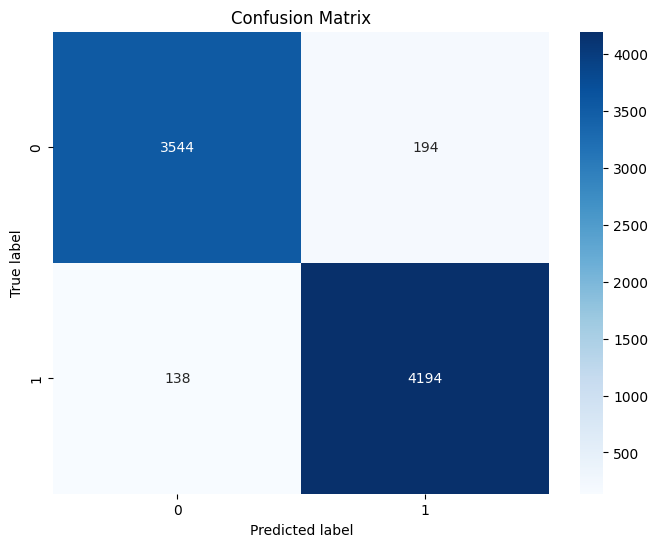

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()